In [17]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/Chocolate_Sales_Curated.csv")
df

,sales_person,country,product,date,amount,boxes_shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397


In [18]:
# Total revenue (amount) by country
revenue_country = df.groupby("country")["amount"].sum().sort_values(ascending=False)
print(revenue_country.head(10))
print('\n\n')
# Total revenue by product
revenue_product = df.groupby("product")["amount"].sum().sort_values(ascending=False)
print(revenue_product.head(10))
print('\n\n')
# Total revenue by salesperson
revenue_salesperson = df.groupby("sales_person")["amount"].sum().sort_values(ascending=False)
print(revenue_salesperson.head(10))

country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: amount, dtype: float64



product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
99% Dark & Pure         960033.45
85% Dark Bars           955268.24
Organic Choco Syrup     945345.73
Spicy Special Slims     938131.69
Mint Chip Choco         904989.55
Name: amount, dtype: float64



sales_person
Ches Bonnell           1022599.96
Oby Sorrel             1017204.12
Madelene Upcott        1010028.72
Kelci Walkden          1002929.10
Brien Boise             997326.48
Van Tuxwell             974425.09
Dennison Crosswaite     931849.57
Beverie Moffet          892421.37
Kaine Padly             849062.76
Marney O'Breen          836427.63
Name: amount, dtype: float64


In [19]:
df["date"] = pd.to_datetime(df["date"], errors='coerce')
df["month"] = df["date"].dt.to_period("M")

# Revenue by month
revenue_month = df.groupby("month")["amount"].sum().sort_index()
print(revenue_month)

month
2022-01     896105.00
2022-02     699377.00
2022-03     749483.00
2022-04     674051.00
2022-05     752892.00
2022-06     865144.00
2022-07     803425.00
2022-08     743148.00
2023-01     958985.77
2023-02     749617.46
2023-03     807494.33
2023-04     727743.72
2023-05     811951.78
2023-06     932625.17
2023-07     861856.66
2023-08     793103.07
2024-01    1013621.82
2024-02     783102.44
2024-03     847791.96
2024-04     760132.50
2024-05     850906.79
2024-06     976162.77
2024-07     902250.63
2024-08     830599.99
Freq: M, Name: amount, dtype: float64


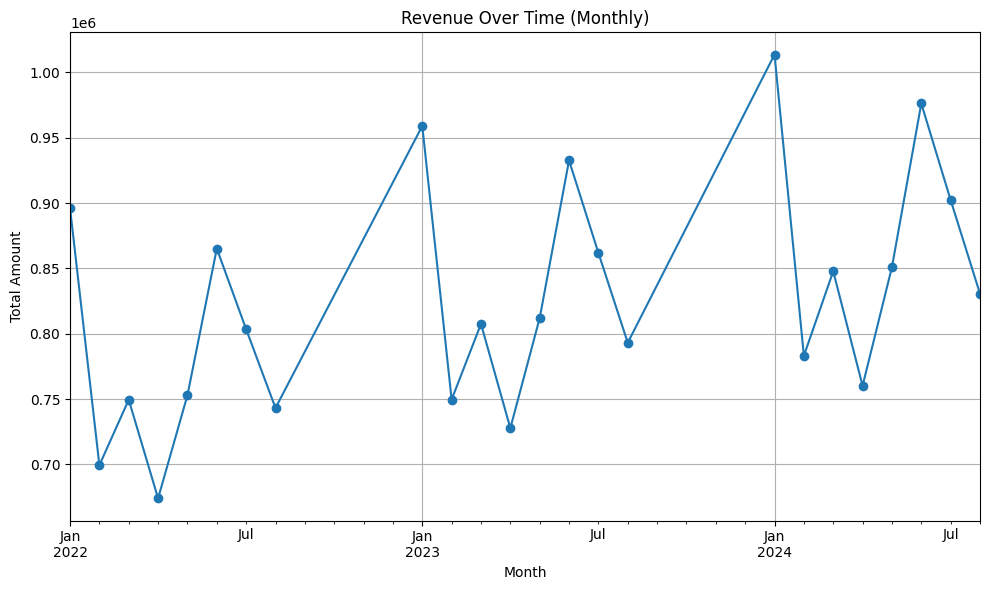

In [20]:
monthly_revenue = df.groupby("month")["amount"].sum()

# Plot line
plt.figure(figsize=(10, 6))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Revenue Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.grid(True)
plt.tight_layout()

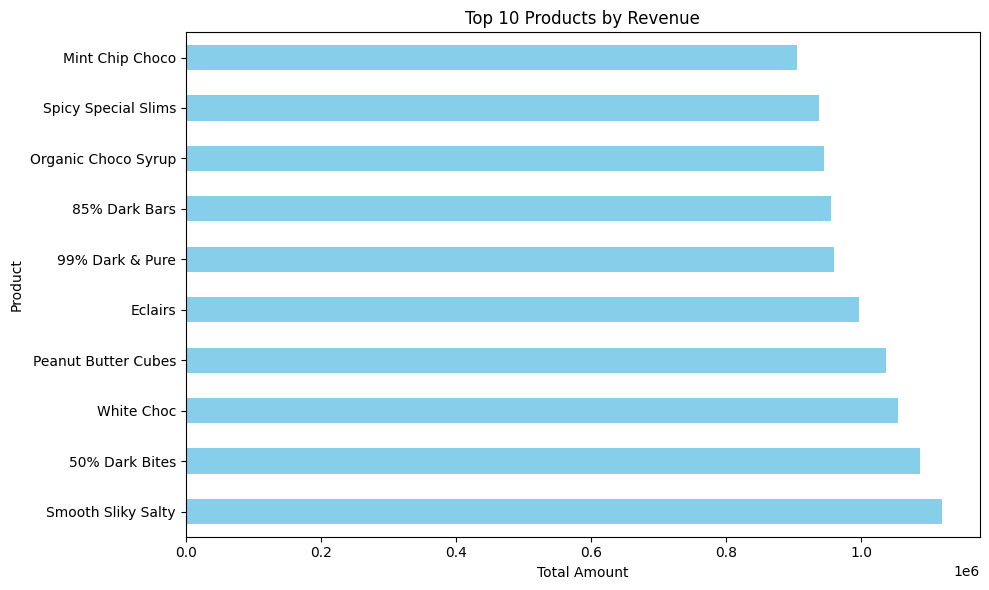

In [21]:
product_revenue = df.groupby("product")["amount"].sum().sort_values(ascending=False).head(10)

# Plot barh
plt.figure(figsize=(10, 6))
product_revenue.plot(kind="barh", color="skyblue")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Amount")
plt.ylabel("Product")
plt.tight_layout()

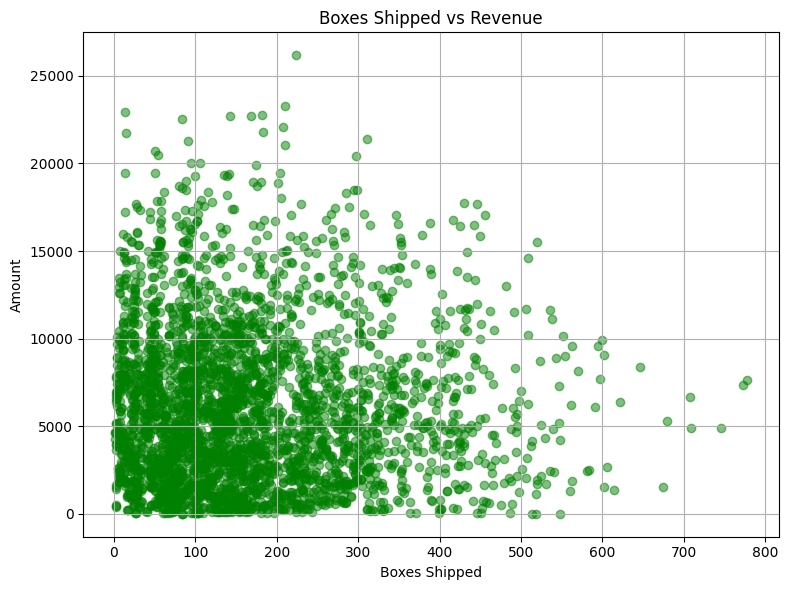

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(df["boxes_shipped"], df["amount"], alpha=0.5, color="green")
plt.title("Boxes Shipped vs Revenue")
plt.xlabel("Boxes Shipped")
plt.ylabel("Amount")
plt.grid(True)
plt.tight_layout()